### Generación de ground truth $\Phi^4_1$

$$
\boxed{dX_t = \left( \Delta X_t + 3X_t - X_t^3 \right) dt + dW_t, \qquad X_0 = \chi_{0}}
$$

**Referencias específicas:** el esquema sigue Apéndice F.1 de Shi et al. (2026), que sigue a `torchspde`. Como F.1 no detalla el método numérico, seguimos Salvi et al. (2022), apéndices A.2 (ruido) y A.3 (solver).

Nuestra versión inicial era espectral en dos partes independientes: el ruido (expansión truncada en modos seno) y el solver de la difusión (FFT). Esto no generó el ground truth correcto, así que adoptamos la implementación de Salvi, cambiando ambas y particularmente adoptando un `esquema de diferencias finitas para el solver`:

> 1. **Ruido:** Browniano 1D independiente por punto de grilla, mezclado con la matriz de correlación espacial completa. Es ruido blanco espacio-temporal cilíndrico ($Q=I$). Bajo $Q=I$ esto equivale a la expansión espectral de la teoría de Shi, pero se realiza como incrementos i.i.d. por punto. (Referencia: https://github.com/andrisger/Feature-Engineering-with-Regularity-Structures en clase `Noise` o directamente `data/` en https://github.com/crispitagorico/torchspde)

> 2. **Solver:** Se optó por implementar manualmente diferencias finitas semi-implícito: Laplaciano tridiagonal implícito en la difusión, reacción $3X-X^3$ explícita.

Además, acorde a Salvi, se consideró una condición inicial base $x(1-x)$ y grilla $N_x+1=129$ (considera extremos del toro).

In [38]:
import numpy as np

# ---------------- Parametros (F.1 / torchspde) ----------------
a, bnd = 0.0, 1.0  # dominio espacial [0,1]
s, T = 0.0, 0.05  # intervalo temporal
dx, dt = 1.0 / 128, 1.0 / 1000  # incrementos (-> Nx+1=129 puntos, Nt+1=51)
sigma = (
    0.1  # intensidad del ruido (se aplica a W: 0.1*W, no explicito en ecuacion inicial)
)
eps = 1.0  # viscosidad (coef. del Laplaciano)


def partition(a, b, h):  # malla [a,b] paso h (incluye extremos)
    return np.linspace(a, b, int((b - a) / h) + 1)


O_X, O_T = partition(a, bnd, dx), partition(s, T, dt)
Nx1, Nt1 = len(O_X), len(O_T)  # 129, 51
print(f"grilla espacio={Nx1} (Nx+1)  tiempo={Nt1} (Nt+1)  sigma={sigma}")

grilla espacio=129 (Nx+1)  tiempo=51 (Nt+1)  sigma=0.1


In [39]:
# ---------------- Ruido blanco espacio-temporal (adaptado de Noise.WN_space_time) ----------------
# Construccion del libro Lord-Powell-Shardlow (Ej. 10.31):
#   - un movimiento browniano 1D INDEPENDIENTE por cada punto de grilla (N columnas)
#   - se mezclan con la matriz de correlacion espacial completa  c(x,j)=sqrt(2/Lc) sin(j pi x/Lc)
#   - Lc = dx*(N-1) = longitud efectiva del dominio
def BM(start, stop, dt, l):
    """l brownianos 1D en [start,stop] paso dt -> (n_t, l), B_0=0."""
    npart = len(partition(start, stop, dt))
    B = np.random.normal(scale=np.sqrt(dt), size=(npart, l))
    B[0] = 0.0
    return np.cumsum(B, axis=0)


def WN_space_time_single(rng_seed=None):
    """Una realizacion de ruido ACUMULADO W (Nt+1, Nx+1)."""
    if rng_seed is not None:
        np.random.seed(rng_seed)
    N = Nx1  # 129
    Lc = dx * (N - 1)  # 1.0
    # matriz de correlacion espacial NxN:  corr[x,j] = sqrt(2/Lc) sin(j pi x / Lc)
    corr = np.array(
        [
            [np.sqrt(2.0 / Lc) * np.sin(j * np.pi * x / Lc) for j in range(N)]
            for x in O_X
        ]
    )
    B = BM(s, T, dt, N)  # (Nt+1, N) brownianos por punto
    return (
        B @ corr.T
    )  # (Nt+1, Nx+1) ruido acumulado correlacionado (Salvi A.2.2 ec. (9))

In [40]:
# ---------------- Condiciones iniciales ----------------
def ci_base():
    """CI determinista de x(1-x)"""
    return O_X * (1.0 - O_X)


def ci_estocastica(rng, p=10, decay=2, scaling=1.0):
    """CI aleatoria: sum_k a_k sin(k pi x/scale)/(|k|+1)^decay,
    superpuesta a x(1-x), escala 0.1.  (tarea (X0,W)->X).
    Esta es la considerada en Salvi (sección 4.1).
    """
    scale = O_X.max() / scaling
    SIN = np.array(
        [
            [
                np.sin(k * np.pi * xx / scale) / ((abs(k) + 1) ** decay)
                for k in range(-p, p + 1)
            ]
            for xx in O_X
        ]
    )
    coef = rng.standard_normal(2 * p + 1)
    extra = rng.standard_normal()
    ic = SIN @ coef + extra
    ic[-1] = ic[0]  # periodicidad exacta
    return 0.1 * (ic - ic[0]) + ci_base()

In [41]:
M = matriz_de_diferencias_finitas(3, dt, dx, eps).T

In [42]:
M

array([[0.18812005, 0.16818066, 0.15850621, 0.15850621],
       [0.32668687, 0.34662626, 0.32668687, 0.32668687],
       [0.32668687, 0.32668687, 0.34662626, 0.32668687],
       [0.15850621, 0.15850621, 0.16818066, 0.18812005]])

In [43]:
# ---------------- Solver de DIFERENCIAS FINITAS (adaptado de SPDE.Parabolic) ----------------
# Esquema semi-implicito:  u_{n+1} = (I - dt/dx^2 A)^{-1} [ u_n + mu(u_n) dt + sigma dW_{n+1} ]
#   A = Laplaciano tridiagonal periodico (3 puntos);  mu(u)=3u-u^3 (reaccion explicita).
def matriz_parabolica(N, dt, dx, eps=1.0):
    """(N+1)x(N+1):  (I - eps*dt/dx^2 A)^{-1},  A Laplaciano discreto periodico."""
    A = (  # matriz de diferencias finitas para el laplaciano.
        np.diag(-2.0 * np.ones(N + 1))
        + np.diag(np.ones(N), 1)
        + np.diag(np.ones(N), -1)
    )
    A[-1, 1], A[0, -2] = 1.0, 1.0  # condiciones de borde periodicas
    return np.linalg.inv(np.identity(N + 1) - eps * dt * A / dx**2)


M = matriz_parabolica(
    Nx1 - 1, dt, dx, eps
).T  # transpuesta: se multiplica por la derecha
mu = np.vectorize(lambda u: 3.0 * u - u**3)  # drift Phi^4_1


def resolver(IC, W):
    """IC:(Nx+1,)  W:(Nt+1,Nx+1) ruido ACUMULADO ya escalado por sigma.
    Devuelve la trayectoria (Nt+1, Nx+1)."""
    dW = np.zeros_like(W)
    dW[1:] = np.diff(W, axis=0)  # incrementos
    sol = np.zeros_like(W)
    sol[0] = IC
    for i in range(1, Nt1):
        cur = sol[i - 1] + mu(sol[i - 1]) * dt + dW[i]  # reaccion explicita + ruido
        sol[i] = cur @ M  # paso implicito (difusion)
    return sol.astype(np.float32)

In [44]:
# ---------------- Generador de dataset ----------------
def generar_dataset(N, seed, ci="base"):
    """Devuelve (W, X): ruido acumulado y solucion, ambos (N, Nt+1, Nx+1).
    El ruido se escala por sigma (0.1*W) al entrar al solver, como en torchspde."""
    rng = np.random.default_rng(seed)
    np.random.seed(seed)  # BM usa el RNG global de numpy
    W = np.zeros((N, Nt1, Nx1), np.float32)
    X = np.zeros((N, Nt1, Nx1), np.float32)
    for i in range(N):
        Wi = WN_space_time_single()  # ruido acumulado
        IC = ci_base() if ci == "base" else ci_estocastica(rng)
        X[i] = resolver(IC, sigma * Wi)  # 0.1*W al solver
        W[i] = sigma * Wi  # guardamos el ruido ya escalado
    return W, X

In [45]:
###### Dataset oficial (1000 train + 200 test siguiendo Shi) ######
N_TRAIN, N_TEST = 1000, 200
S_TR, S_TE = 2024, 7777  # semillas separadas train/test


def guardar(fname, Wtr, Xtr, Wte, Xte, **extra):
    np.savez_compressed(
        fname,
        W_train=Wtr,
        X_train=Xtr,
        W_test=Wte,
        X_test=Xte,
        dx=dx,
        dt=dt,
        T=T,
        sigma=sigma,
        N_train=N_TRAIN,
        N_test=N_TEST,
        **extra,
    )
    print(f"guardado {fname} | train {Xtr.shape} test {Xte.shape}")


# Tarea 1:  W -> X   (CI = x(1-x))
Wtr, Xtr = generar_dataset(N_TRAIN, S_TR, ci="base")
Wte, Xte = generar_dataset(N_TEST, S_TE, ci="base")
guardar("phi41_train_Wmap.npz", Wtr, Xtr, Wte, Xte, seed_train=S_TR, seed_test=S_TE)

# Tarea 2:  (X0,W) -> X   (CI estocastica)
Wtr2, Xtr2 = generar_dataset(N_TRAIN, S_TR + 1, ci="estocastica")
Wte2, Xte2 = generar_dataset(N_TEST, S_TE + 1, ci="estocastica")
guardar(
    "phi41_train_X0Wmap.npz",
    Wtr2,
    Xtr2,
    Wte2,
    Xte2,
    seed_train=S_TR + 1,
    seed_test=S_TE + 1,
)

guardado phi41_train_Wmap.npz | train (1000, 51, 129) test (200, 51, 129)
guardado phi41_train_X0Wmap.npz | train (1000, 51, 129) test (200, 51, 129)


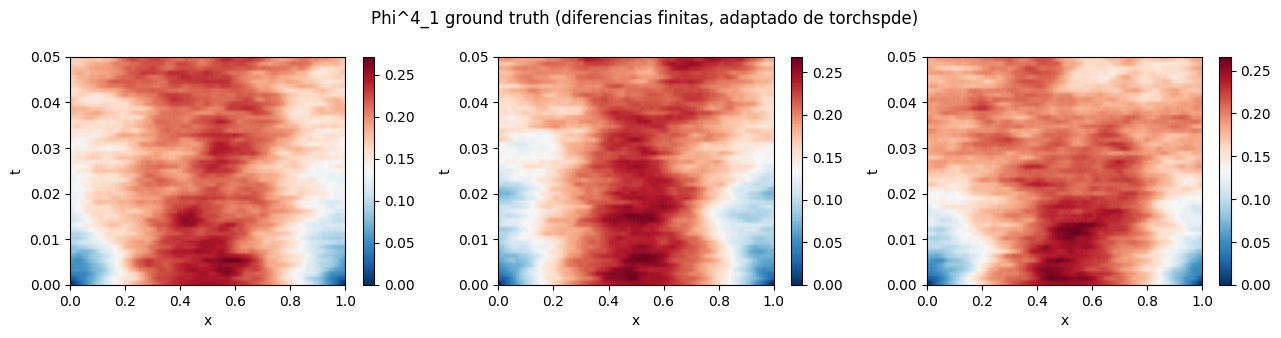

rango X final: 0.1681 0.2388


In [46]:
# Comprobación final:
import matplotlib.pyplot as plt

Wd, Xd = generar_dataset(3, 0, ci="base")
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for i in range(3):
    im = ax[i].imshow(
        Xd[i], aspect="auto", origin="lower", extent=[0, bnd, 0, T], cmap="RdBu_r"
    )
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("t")
    fig.colorbar(im, ax=ax[i])
plt.suptitle("Phi^4_1 ground truth (diferencias finitas, adaptado de torchspde)")
plt.tight_layout()
plt.show()
print(
    "rango X final:", round(float(Xd[0, -1].min()), 4), round(float(Xd[0, -1].max()), 4)
)